## DDIM inversion (initalise with MCPL pretrained)

In [92]:
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager,Embed_control_manager
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer
import torch
import os


from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler,StableDiffusionPipeline,DDIMScheduler
from causal_modules import ddim_modules
size = 256

image_transforms = transforms.Compose(
        [
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
        )
original_transforms = transforms.Compose(
        [
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
        ]
        )

conditioning_image_transforms = transforms.Compose(
            [
                transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
                transforms.ToTensor(),
                #transforms.Normalize([0.5], [0.5]),
            ]
        )
        

In [43]:
def load_mcpl_embeddings(base_model_path,tokenizer,embedding_path=None,presudo_token_ids=None,embed_control=True):
    text_encoder = CLIPTextModel.from_pretrained(
        base_model_path, subfolder="text_encoder"
    )
    if embedding_path is not None:
        state_dict = load_state_dict(embedding_path)
        embeddings = []
        tokens = []
        for key,embed in state_dict.items():
            tokens.append(key)
            embeddings.append(embed)
        token_ids = tokenizer.encode(tokens, add_special_tokens=False)
        # 7.4 Load token and embedding
        for token_id, embedding in zip(token_ids, embeddings):
            # add tokens and get ids
            # tokenizer.add_tokens(token)
            # token_id = tokenizer.convert_tokens_to_ids(token)
            text_encoder.get_input_embeddings().weight.data[token_id] = embedding
            print(f"Loaded textual inversion embedding for {token_id}.")


        embed_proj_path  = embedding_path.replace("learned_embeds", "embeds_proj")
            
        if os.path.exists(embed_proj_path):
            embedding_manager = EmbeddingManager(token_ids)
            text_encoder.text_model.embeddings.set_embedding_manager(embedding_manager)
            linear_state_dict = load_state_dict(embed_proj_path)
            embedding_manager.embed_proj.load_state_dict(linear_state_dict)
            embedding_manager.eval()
            print('extend projection')

    

    text_encoder.eval()
    return text_encoder


def change_mcpl_embeddings(new_text_encoder,tokenizer,embedding_path=None,edit_token=None):
    
    if embedding_path is not None:
        state_dict = load_state_dict(embedding_path)
        embeddings = []
        tokens = []
        for key,embed in state_dict.items():
            tokens.append(key)
            embeddings.append(embed)
        token_ids = tokenizer.encode(tokens, add_special_tokens=False)
        # 7.4 Load token and embedding
        for token_id, embedding in zip(token_ids, embeddings):
            # add tokens and get ids
            # tokenizer.add_tokens(token)
            # token_id = tokenizer.convert_tokens_to_ids(token)
            if edit_token==token_id:
                print(f"Loaded textual inversion embedding for {token_id}.")
                new_text_encoder.get_input_embeddings().weight.data[token_id] = embedding
            

    new_text_encoder.eval()
    return new_text_encoder
            


In [ ]:
tokenizer.encode(prompt)

: 

In [93]:
'''Load pipeline'''


base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"


mcpl_embedding_path = "../logs/logs_pendulum_data100/2025-05-20T17-18-10-mcpl-one-r2/learned_embeds-steps-6000.safetensors"
#mcpl_embedding_path = "../logs/logs_pendulum_data100/2025-05-20T17-39-52-mcpl-one-r2/learned_embeds-steps-6000.safetensors"


# Load mcpl embedding
#prompt = "a people photo of young and female and beard and bald"
prompt = 'a photo of a orange @ and shaking * and black & and black !'
#prompt = '@ * & !'
presudo_words= '@,*,&,!'
#presudo_words = 'young,female,beard,bald'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
embed_control_manager_bool = True

text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids,embed_control=embed_control_manager_bool)

pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,text_encoder=text_encoder ,torch_dtype=torch.float32
)
# pipe.scheduler = UniPCMultistepScheduler.from_config(
#     pipe.scheduler.config
# )
pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config
)
pipe.safety_checker = None
pipe.requires_safety_checker = False
device = torch.device("cuda")
pipe = pipe.to(device)



Loaded textual inversion embedding for 256.
Loaded textual inversion embedding for 261.
Loaded textual inversion embedding for 265.
Loaded textual inversion embedding for 287.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76

  0%|          | 0/50 [00:00<?, ?it/s]

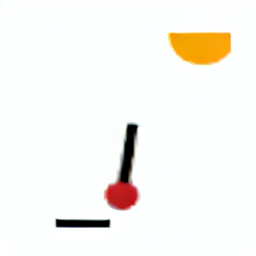

In [94]:
generator = torch.manual_seed(torch.randint(0, 10000, (1,)).item())
recons_image = pipe(
    prompt, num_inference_steps=50,height=256,width=256,guidance_scale=5.0,negative_prompt=None,num_images_per_prompt=3
).images
recons_image[0]

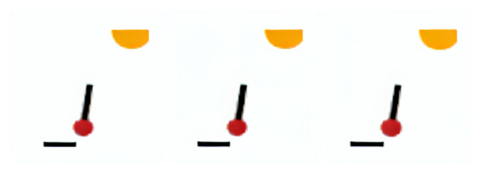

In [95]:
ddim_modules.save_images_grid([recons_image],(1,len(recons_image)),None)

  0%|          | 0/50 [00:00<?, ?it/s]

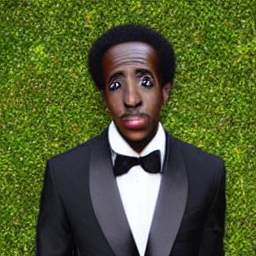

In [63]:
generator = torch.manual_seed(torch.randint(0, 10000, (1,)).item())
#new_prompt = 'a photo of a orange @ and shaking * and black & and black !'
new_prompt = 'a photo of black !'
recons_image = pipe(
    new_prompt, num_inference_steps=50, generator=generator,height=256,width=256,guidance_scale=7.5,negative_prompt=None
).images[0]
recons_image

In [185]:
'''Load pipeline'''
from copy import deepcopy


new_mcpl_embedding_path = "../logs/logs_pendulum_data100/2025-05-20T16-57-24-mcpl-one-r2/learned_embeds-steps-6000.safetensors"

edit_token_id = 3
new_text_encoder = deepcopy(text_encoder)
new_text_encoder = change_mcpl_embeddings(new_text_encoder,tokenizer,new_mcpl_embedding_path,presudo_token_ids[edit_token_id])

new_pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,text_encoder=new_text_encoder ,torch_dtype=torch.float32
)
# new_pipe.scheduler = UniPCMultistepScheduler.from_config(
#     new_pipe.scheduler.config
# )
pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config
)
new_pipe.safety_checker = None
new_pipe.requires_safety_checker = False

new_pipe = new_pipe.to(device)



Loaded textual inversion embedding for 256.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76

  0%|          | 0/50 [00:00<?, ?it/s]

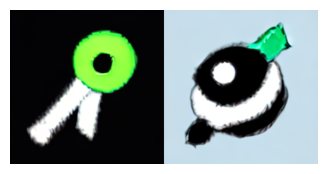

In [186]:
generator = torch.manual_seed(torch.randint(0, 10000, (1,)).item())
recons_image = new_pipe(
    prompt, num_inference_steps=50,height=256,width=256,guidance_scale=7.5,negative_prompt=None,num_images_per_prompt=2
).images
ddim_modules.save_images_grid([recons_image],(1,len(recons_image)),None)

In [187]:
from tqdm import tqdm
# Sample function (regular DDIM)
@torch.no_grad()
def sample(
    pipe,
    prompt,
    start_step=0,
    start_latents=None,
    guidance_scale=3.5,
    num_inference_steps=30,
    num_images_per_prompt=1,
    negative_prompt="",
    device=device,
    controlnet_image=None,
    intervention_indx=None,
    intervention_values=None,
    label=None,
    return_PIL = True,
    
):
    if guidance_scale>1:
        do_classifier_free_guidance = True
    else:
        do_classifier_free_guidance= False    

    start_latents, prompt, label = ddim_modules.align_batch_size(start_latents, prompt, label)
    
    _,negtive_prompt_embedding = pipe.encode_prompt(
        prompt, device, num_images_per_prompt, do_classifier_free_guidance, negative_prompt
    )
    input_ids = pipe.tokenizer(prompt,
                        padding="max_length",
                        truncation=True,
                        max_length=pipe.tokenizer.model_max_length,
                        return_tensors="pt",
                    ).input_ids.to(device)
    if input_ids.dim() ==1:
        input_ids=input_ids.unsqueeze(0)


    pipe.scheduler.set_timesteps(num_inference_steps, device=device)

    # Create a random starting point if we don't have one already
    if start_latents is None:
        start_latents = torch.randn(1, 4, 32, 32, device=device)
        start_latents *= pipe.scheduler.init_noise_sigma
    
    start_latents, label = start_latents.to(device),label.to(device)

    latents = start_latents.clone()
    
    for i in tqdm(range(start_step, num_inference_steps)):

        t = pipe.scheduler.timesteps[i]

        # Expand the latents if we are doing classifier free guidance
        latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
        latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

    
        encoder_hidden_states = pipe.text_encoder(input_ids)[0].to(dtype=latent_model_input.dtype)
        if do_classifier_free_guidance:
            if negtive_prompt_embedding is not None:
                encoder_hidden_states = torch.cat([negtive_prompt_embedding, encoder_hidden_states])
            else:
                assert encoder_hidden_states is not None, 'negative_prompt_embedding should be provided when do_classifier_free_guidance is True'



        # Predict the noise residual
        noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=encoder_hidden_states,
                    return_dict=False)[0]

        # Perform guidance
        if do_classifier_free_guidance:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        # Normally we'd rely on the scheduler to handle the update step:
        # latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample
        #latents = pipe.scheduler.step(noise_pred, t, latents, return_dict=False)[0]
        # Instead, let's do it ourselves:
        prev_t = max(1, t.item() - (1000 // num_inference_steps))  # t-1
        alpha_t = pipe.scheduler.alphas_cumprod[t.item()]
        alpha_t_prev = pipe.scheduler.alphas_cumprod[prev_t]
        predicted_x0 = (latents - (1 - alpha_t).sqrt() * noise_pred) / alpha_t.sqrt()
        direction_pointing_to_xt = (1 - alpha_t_prev).sqrt() * noise_pred
        latents = alpha_t_prev.sqrt() * predicted_x0 + direction_pointing_to_xt

    # Post-processing
    images = pipe.vae.decode(latents/ pipe.vae.config.scaling_factor,return_dict=False)[0]
    if return_PIL:
        do_denormalize = [True] * images.shape[0]
        output = pipe.image_processor.postprocess(images,do_denormalize=do_denormalize)
    else:
        output = images
    return output

## Inversion
@torch.no_grad()
def invert(
    pipe,
    start_latents,
    prompt,
    guidance_scale=1,
    num_inference_steps=80,
    num_images_per_prompt=1,
    negative_prompt="",
    device=device,
    controlnet_image=None,
    intervention_indx=None,
    intervention_values=None,
    label=None,
):    
    if guidance_scale>1:
        do_classifier_free_guidance = True
    else:
        do_classifier_free_guidance= False    

    # # Encode prompt
    start_latents, prompt, label = ddim_modules.align_batch_size(start_latents, prompt, label)
    
    _,negtive_prompt_embedding = pipe.encode_prompt(
        prompt, device, num_images_per_prompt, do_classifier_free_guidance, negative_prompt
    )
    input_ids = pipe.tokenizer(prompt,
                        padding="max_length",
                        truncation=True,
                        max_length=pipe.tokenizer.model_max_length,
                        return_tensors="pt",
                    ).input_ids.to(device)
    if input_ids.dim() ==1:
        input_ids=input_ids.unsqueeze(0)
    
    
    # Create a random starting point if we don't have one already
    if start_latents is None:
        start_latents = torch.randn(1, 4, 32, 32, device=device)
        start_latents *= pipe.scheduler.init_noise_sigma
    # Latents are now the specified start latents
    start_latents, label = start_latents.to(device),label.to(device)
    latents = start_latents.clone()

    # We'll keep a list of the inverted latents as the process goes on
    intermediate_latents = []

    # Set num inference steps
    pipe.scheduler.set_timesteps(num_inference_steps, device=device)

    # Reversed timesteps <<<<<<<<<<<<<<<<<<<<
    timesteps = reversed(pipe.scheduler.timesteps)
    for i in tqdm(range(1, num_inference_steps), total=num_inference_steps - 1):

        # We'll skip the final iteration
        if i >= num_inference_steps - 1:
            continue

        t = timesteps[i]

        # Expand the latents if we are doing classifier free guidance
        latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
        latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

    
        encoder_hidden_states = pipe.text_encoder(input_ids)[0].to(dtype=latent_model_input.dtype)
        if do_classifier_free_guidance:
            if negtive_prompt_embedding is not None:
                encoder_hidden_states = torch.cat([negtive_prompt_embedding, encoder_hidden_states])
            else:
                assert encoder_hidden_states is not None, 'negative_prompt_embedding should be provided when do_classifier_free_guidance is True'

        
        
        # Predict the noise residual
        noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=encoder_hidden_states,
                    return_dict=False)[0]
        #noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=encoder_hidden_states, return_dict=False)[0]
        

        # Perform guidance
        if guidance_scale>1:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        current_t = max(0, t.item() - (1000 // num_inference_steps))  # t
        next_t = t  # min(999, t.item() + (1000//num_inference_steps)) # t+1
        alpha_t = pipe.scheduler.alphas_cumprod[current_t]
        alpha_t_next = pipe.scheduler.alphas_cumprod[next_t]

        # Inverted update step (re-arranging the update step to get x(t) (new latents) as a function of x(t-1) (current latents)
        latents = (latents - (1 - alpha_t).sqrt() * noise_pred) * (alpha_t_next.sqrt() / alpha_t.sqrt()) + (
            1 - alpha_t_next
        ).sqrt() * noise_pred

        # Store
        intermediate_latents.append(latents)

    return torch.stack(intermediate_latents, dim=0)

In [188]:
image_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/pendulum_test/2/a_-8_61_5_4.png'
image_label = list(map(int,image_path[:-4].split("/")[-1].split('_')[1:]))
image = Image.open(image_path).convert("RGB")
if not image.mode == "RGB":
    image = image.convert("RGB")


original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image).unsqueeze(0)
label = torch.tensor(image_label).unsqueeze(0).to(device)


In [189]:
generator = torch.manual_seed(torch.randint(0, 10000, (1,)).item())
with torch.no_grad():
    latent = pipe.vae.encode(image.to(device))
    img_latent = 0.18215 * latent.latent_dist.sample()
# Keep inversion guidance scale to 1 will protect the identity
invert_guidance_scale = 1.0
num_steps = 50
inverted_latents = invert(pipe,
        img_latent,
        prompt,
        guidance_scale=invert_guidance_scale,
        num_inference_steps=num_steps,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=None,
        intervention_values=None,
        label=label.clone())

  0%|          | 0/49 [00:00<?, ?it/s]

100%|██████████| 49/49 [00:02<00:00, 22.76it/s]


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:02<00:00, 19.79it/s]


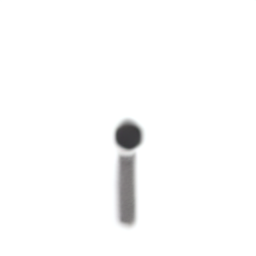

In [191]:
s_step = 0
final_im = sample(
        new_pipe,
        prompt,
        start_step=s_step,
        start_latents=inverted_latents[-(s_step + 1)].clone(),
        guidance_scale=5.0,
        num_inference_steps=num_steps,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=None,
        intervention_values=None,
        label=label.clone(),
        return_PIL = True,
    )
final_im[0]

100%|██████████| 50/50 [00:02<00:00, 18.14it/s]


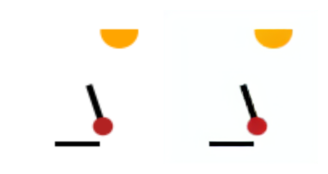

In [28]:

image = img
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image) 

set_guidance_scale  = 1.0
num_steps = 50
s_step = 0
final_im,inverted_latents,_ = ddim_editing(pipe, image.unsqueeze(0),label.clone(),prompt,num_steps = num_steps,invert_guidance_scale=1.0,set_guidance_scale  = set_guidance_scale,intervention_indx=None,intervention_values=None,return_PIL=True)
        
to_pil =  transforms.ToPILImage()
save_images_grid([[original_img, final_im[0]]],(1,2),None)

100%|██████████| 50/50 [00:02<00:00, 17.66it/s]


save imgs in ./intervention_variable3.png


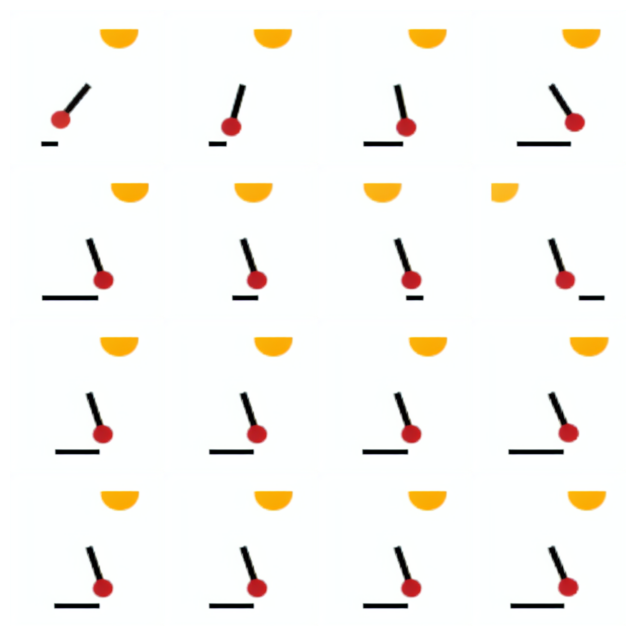

: 

In [ ]:

# Do intervention
image_lists = []
range_len = 4
inter_value = [np.linspace(-1.0, 0.8, num=range_len),
                np.linspace(-1.0, 0.9, num=range_len),
                np.linspace(-1.0, 1.0, num=range_len),
                np.linspace(-1.0, 1.0, num=range_len),
                ] 
for inter_id in range(0,4,1):
    images = []
    #inter_value  = -1
    for i in range(range_len): 
        s_step = 0
        interved_image,causal_cond = sample(
            pipe,
            prompt,
            start_step=s_step,
            #start_latents=None,
            start_latents=inverted_latents[-(s_step + 1)].clone(),
            guidance_scale=1.0,
            num_inference_steps=num_steps,
            num_images_per_prompt=1,
            negative_prompt=None,
            device=device,
            controlnet_image=None,
            intervention_indx=inter_id,
            intervention_values=inter_value[inter_id][i],
            label=label.clone(),
            return_PIL = True
        )
        #print(causal_cond)
        images.append(interved_image[0])
        

    image_lists.append([np.asarray(img) for img in images])
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid(image_lists,(4,range_len),save_path)
print('save imgs in {}'.format(save_path))

# Plot Attn Maps

In [15]:
import os
prompts = [prompt]
out_base = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/outputs/attention_maps/'
exp_name = 'textcond'
if not os.path.exists(out_base):
    os.mkdir(out_base) 
out_path_base = os.path.join(out_base, exp_name)
if not os.path.exists(out_path_base):
    os.mkdir(out_path_base) 
out_path_prompt = os.path.join(out_path_base, prompts[0])
if not os.path.exists(out_path_prompt):
    os.mkdir(out_path_prompt)
out_dir = out_path_prompt
out_name = 'causalnet'+'.png'

ax shape: (1, 7)


100%|██████████| 49/49 [00:02<00:00, 17.81it/s]


  0%|          | 0/50 [00:00<?, ?it/s]

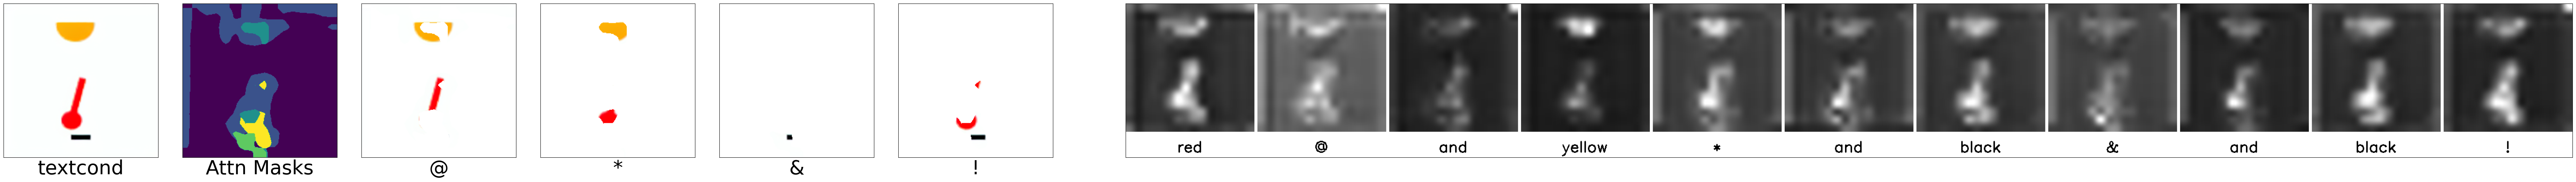

<Figure size 640x480 with 0 Axes>

In [17]:
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from scripts.show_attn_maps import ptp_tools,ptp_utils
import importlib
importlib.reload(ptp_tools)
importlib.reload(ptp_utils)
attn_threshold = 0.5

# pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
#     base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
# )
# pipe.scheduler = DDIMScheduler.from_config(
#     pipe.scheduler.config
# )
# pipe.safety_checker = None
# pipe.requires_safety_checker = False
# #pipe.load_mcpl_inversion(mcpl_embedding_path)


# # memory optimization.
# #pipe.enable_model_cpu_offload()
# pipe = pipe.to(device)

ptp_tools.plot_img_attn_mask_textcontrol(pipe, prompts,presudo_words,condition_image, \
        device, out_dir, out_name, latent=img_latent,res=16,label=label, \
        GUIDANCE_SCALE=1,attn_threshold=attn_threshold, only_sampling=False,\
        intervention_indx=None,intervention_values=None,from_where=['down','up'],mask_concepts=True, g_gpu=generator,num_steps=50,img_size=size,exp_names=[exp_name])

In [ ]:
import torch
from torch.nn import functional as F
def kl_normal(qm, qv, pm, pv):
    """
    Computes the elem-wise KL divergence between two normal distributions KL(q || p) and
    sum over the last dimension

    Args:
        qm: tensor: (batch, dim): q mean
        qv: tensor: (batch, dim): q variance
        pm: tensor: (batch, dim): p mean
        pv: tensor: (batch, dim): p variance

    Return:
        kl: tensor: (batch,): kl between each sample
    """
    element_wise = 0.5 * (torch.log(pv) - torch.log(qv) + qv / pv + (qm - pm).pow(2) / pv - 1)
    print(element_wise)
    kl = element_wise.sum(-1)

    return kl

q_m = torch.tensor([[2.0,3.0,3.0,5.0],[2.0,3.0,3.0,5.0]])
p_m  = torch.tensor([[0.0,0.0,1.0,2.5],[0.0,0.0,1.0,2.5]])
print(kl_normal(q_m,torch.ones((q_m.shape)),p_m,torch.ones((q_m.shape))))
print(0.5*F.mse_loss(q_m,p_m,reduction='sum'))

tensor([[2.0000, 4.5000, 2.0000, 3.1250],
        [2.0000, 4.5000, 2.0000, 3.1250]])
tensor([11.6250, 11.6250])
tensor(23.2500)


In [ ]:
def dataset_load_path(data_root='/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/test'):
    # name like sampling_100 , sampling_500 dir
    image_paths = [os.path.join(data_root, file_path) for file_path in os.listdir(data_root)]
    label_list = [list(map(int,k[:-4].split("/")[-1].split('_')[1:])) for k in image_paths]
    scale = np.array([[0,44],[100,40],[6.5, 3.5],[10,5]])
    img_id = random.randint(0,len(image_paths))
    print(image_paths[img_id])
    print(label_list[img_id])

    
    label = torch.from_numpy(np.asarray(label_list[img_id]))
    array1 = np.asarray(label).astype(np.float32)
    label = torch.from_numpy(array1)
    norm_label = torch.zeros(label.shape)        
    for i in range(label.shape[0]):
        norm_label[i] = (label[i] - scale[i][0]) / scale[i][1]
    print('norm label',norm_label)
    
    return image_paths[img_id],norm_label

data_root = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/train'
image_paths = [os.path.join(data_root, file_path) for file_path in os.listdir(data_root)]
label_list1 = [list(map(int, k[:-4].split("/")[-1].split('_')[1:])) for k in image_paths]

# Load test labels
data_root = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/test'
image_paths = [os.path.join(data_root, file_path) for file_path in os.listdir(data_root)]
label_list2 = [list(map(int, k[:-4].split("/")[-1].split('_')[1:])) for k in image_paths]

# Concatenate label lists
all_labels = np.array(label_list1 + label_list2)

# Compute column-wise min and max
col_min = all_labels.min(axis=0)
col_max = all_labels.max(axis=0)

print("Column-wise min values:", col_min)
print("Column-wise max values:", col_max)



Column-wise min values: [-40  60   3   2]
Column-wise max values: [ 43 147  12  19]


In [26]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

A = torch.tensor([
    [0, 1, 0, 0],
    [0, 0, 1, 1],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
], dtype=torch.float32).to(device)

def get_reason_and_result_variable_indices(A):
    reason_variable_indices = []
    result_variable_indices = []

    for i in range(A.size(1)):
        col = A[:, i]

        if torch.all(col == 0):
            reason_variable_indices.append(i)
        if torch.any(col != 0):
            result_variable_indices.append(i)
    
    return reason_variable_indices, result_variable_indices

reason_v_indices, result_v_indices = get_reason_and_result_variable_indices(A)
print("Reason variable indices:", reason_v_indices)
print("Result variable indices:", result_v_indices)


Reason variable indices: [0]
Result variable indices: [1, 2, 3]
